# 03 · Cascaded Inference Pipeline

This notebook demonstrates the full two-stage inference system:

```
Input Image
    │
    ▼
┌─────────────────────────────────────┐
│  Stage 1 : ResNet50                 │
│  → softmax over 53 classes          │
│  → top-1 confidence                 │
└────────────────┬────────────────────┘
                 │  conf >= threshold?
         Yes ───►│◄─── No (still pass, flag low-conf)
                 ▼
┌─────────────────────────────────────┐
│  Stage 2 : EfficientNetB0           │
│  → final softmax prediction         │
└────────────────┬────────────────────┘
                 ▼
     { plant, disease, confidence }
```

| Notebook | Covers |
|----------|--------|
| This one | Load models → single inference → batch inference → Top-5 bar chart |


## 0 · Environment

In [1]:
import sys, os, glob
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
import keras
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img
# from keras.src.engine import functional

print("Imports OK")

Imports OK


## 1 · Configuration

In [2]:
DATA_DIR          = "../data"
RESNET_PATH       = "../models/resnet_model.h5"
EFFICIENTNET_PATH = "../models/efficientnet_model.h5"

IMAGE_SIZE        = (224, 224)
CONFIDENCE_THRESHOLD = 0.30   # Stage-1 filter threshold

# ── Load class names (from folder structure) ───────────────────────────
CLASS_NAMES = sorted(
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
)
print(f"Loaded {len(CLASS_NAMES)} class names")

Loaded 58 class names


## 2 · Load both models

In [3]:
print("Loading EfficientNetB0 …")
efficientnet_model = load_model(EFFICIENTNET_PATH, compile=False)
print("✅ EfficientNetB0 loaded")

print("Loading ResNet50 …")
resnet_model = keras.models.load_model(RESNET_PATH, compile=False)
print("✅ ResNet50 loaded")

Loading EfficientNetB0 …
✅ EfficientNetB0 loaded
Loading ResNet50 …
✅ ResNet50 loaded


## 3 · Single-image inference

In [4]:
from src.utils import predict

# ── Pick a sample image ────────────────────────────────────────────────
all_images  = glob.glob(f"{DATA_DIR}/**/*.jpg", recursive=True)
SAMPLE_IMG  = all_images[0]          # change index to try different images

print("Image path :", SAMPLE_IMG)
print("-" * 50)

result = predict(
    image_path         = SAMPLE_IMG,
    resnet_model       = resnet_model,
    efficientnet_model = efficientnet_model,
    class_names        = CLASS_NAMES,
    threshold          = CONFIDENCE_THRESHOLD,
    image_size         = IMAGE_SIZE,
)

print("\n" + "="*50)
print("  PREDICTION RESULT")
print("="*50)
print(f"  Plant           : {result['plant']}")
print(f"  Disease         : {result['disease']}")
print(f"  Confidence      : {result['confidence']:.2%}")
print(f"  Stage-1 conf    : {result['stage1_confidence']:.2%}")
print(f"  High confidence : {result['high_confidence']}")
print("="*50)

Image path : ../data\Apple___black_rot\00e909aa-e3ae-4558-9961-336bb0f35db3___JR_FrgE.S 8593.JPG
--------------------------------------------------
[predict] Stage 1 (Tomato___late_blight) conf=0.999  ✓ High confidence
Raw predictions max prob: 1.0
Predicted class index: 0
[predict] Stage 2 → Plant: Apple | Disease: Black Rot | Confidence: 1.000

  PREDICTION RESULT
  Plant           : Apple
  Disease         : Black Rot
  Confidence      : 100.00%
  Stage-1 conf    : 99.90%
  High confidence : True


### 3a · Visualise prediction + top-5 class probabilities

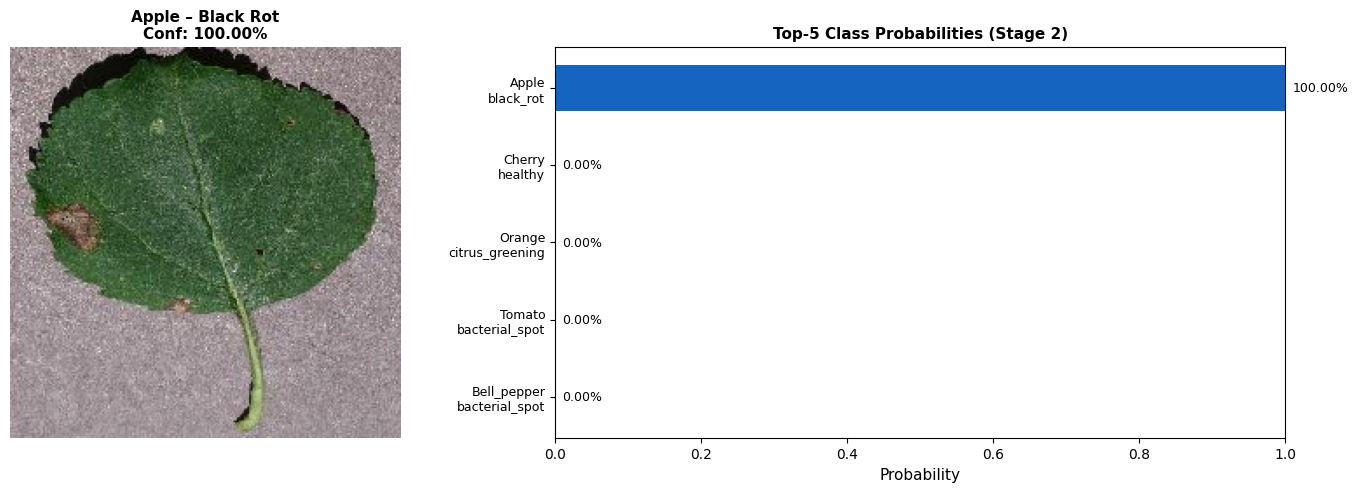

Saved → ../models/sample_prediction.png


In [5]:
probs      = result["all_probs"]                     # (53,)
top5_idx   = np.argsort(probs)[::-1][:5]
top5_names = [CLASS_NAMES[i].replace("___", "\n") for i in top5_idx]
top5_probs = [probs[i] for i in top5_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                          gridspec_kw={"width_ratios": [1, 1.6]})

# Left: original image
img = load_img(SAMPLE_IMG, target_size=IMAGE_SIZE)
axes[0].imshow(img)
axes[0].set_title(
    f"{result['plant']} – {result['disease']}\n"
    f"Conf: {result['confidence']:.2%}",
    fontsize=11, fontweight="bold"
)
axes[0].axis("off")

# Right: top-5 bar chart
colors = ["#1565C0" if i == 0 else "#90CAF9" for i in range(5)]
bars   = axes[1].barh(range(5), top5_probs[::-1], color=colors[::-1], height=0.6)
axes[1].set_yticks(range(5))
axes[1].set_yticklabels(top5_names[::-1], fontsize=9)
axes[1].set_xlabel("Probability", fontsize=11)
axes[1].set_title("Top-5 Class Probabilities (Stage 2)", fontsize=11, fontweight="bold")
axes[1].set_xlim(0, 1)

for bar, prob in zip(bars, top5_probs[::-1]):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{prob:.2%}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../models/sample_prediction.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../models/sample_prediction.png")

## 4 · Batch inference on multiple images

In [6]:
# Test on 12 random images
import random
random.seed(42)
test_images = random.sample(all_images, min(12, len(all_images)))

print(f"Running cascaded inference on {len(test_images)} images …\n")

results = []
for path in test_images:
    r = predict(
        image_path         = path,
        resnet_model       = resnet_model,
        efficientnet_model = efficientnet_model,
        class_names        = CLASS_NAMES,
        threshold          = CONFIDENCE_THRESHOLD,
    )
    r["path"]       = path
    r["true_class"] = os.path.basename(os.path.dirname(path))
    results.append(r)

# Summary table
print("\n" + "-"*90)
print(f"{'True Class':<35}  {'Pred Plant':<15}  {'Pred Disease':<25}  {'Conf':>6}")
print("-"*90)
for r in results:
    correct = "✅" if r["true_class"] == r["predicted_class"] else "❌"
    print(f"{correct} {r['true_class']:<33}  {r['plant']:<15}  {r['disease']:<25}  {r['confidence']:.2%}")
print("-"*90)

Running cascaded inference on 12 images …

[predict] Stage 1 (Tomato___late_blight) conf=0.999  ✓ High confidence
Raw predictions max prob: 0.9998061
Predicted class index: 52
[predict] Stage 2 → Plant: Tomato | Disease: Leaf Curl | Confidence: 1.000
[predict] Stage 1 (Tomato___late_blight) conf=0.999  ✓ High confidence
Raw predictions max prob: 0.9562713
Predicted class index: 10
[predict] Stage 2 → Plant: Cassava | Disease: Healthy | Confidence: 0.956
[predict] Stage 1 (Tomato___late_blight) conf=1.000  ✓ High confidence
Raw predictions max prob: 0.97034115
Predicted class index: 2
[predict] Stage 2 → Plant: Apple | Disease: Healthy | Confidence: 0.970
[predict] Stage 1 (Tomato___late_blight) conf=0.999  ✓ High confidence
Raw predictions max prob: 0.5855221
Predicted class index: 21
[predict] Stage 2 → Plant: Grape | Disease: Isariopsis Leaf Spot | Confidence: 0.586
[predict] Stage 1 (Tomato___late_blight) conf=0.999  ✓ High confidence
Raw predictions max prob: 0.99999464
Predicted c

## 5 · Visualise batch predictions

C:\Users\Prakash Choudhary\AppData\Local\Temp\ipykernel_10640\4219623382.py:26: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Prakash Choudhary\AppData\Local\Temp\ipykernel_10640\4219623382.py:26: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Prakash Choudhary\AppData\Local\Temp\ipykernel_10640\4219623382.py:27: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("../models/batch_predictions.png", dpi=150, bbox_inches="tight")
C:\Users\Prakash Choudhary\AppData\Local\Temp\ipykernel_10640\4219623382.py:27: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("../models/batch_predictions.png", dpi=150, bbox_inches="tight")
c:\Users\Prakash Choudhary\Desktop\Work\Freelancing\Plants Disease detection\Addy\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Gly

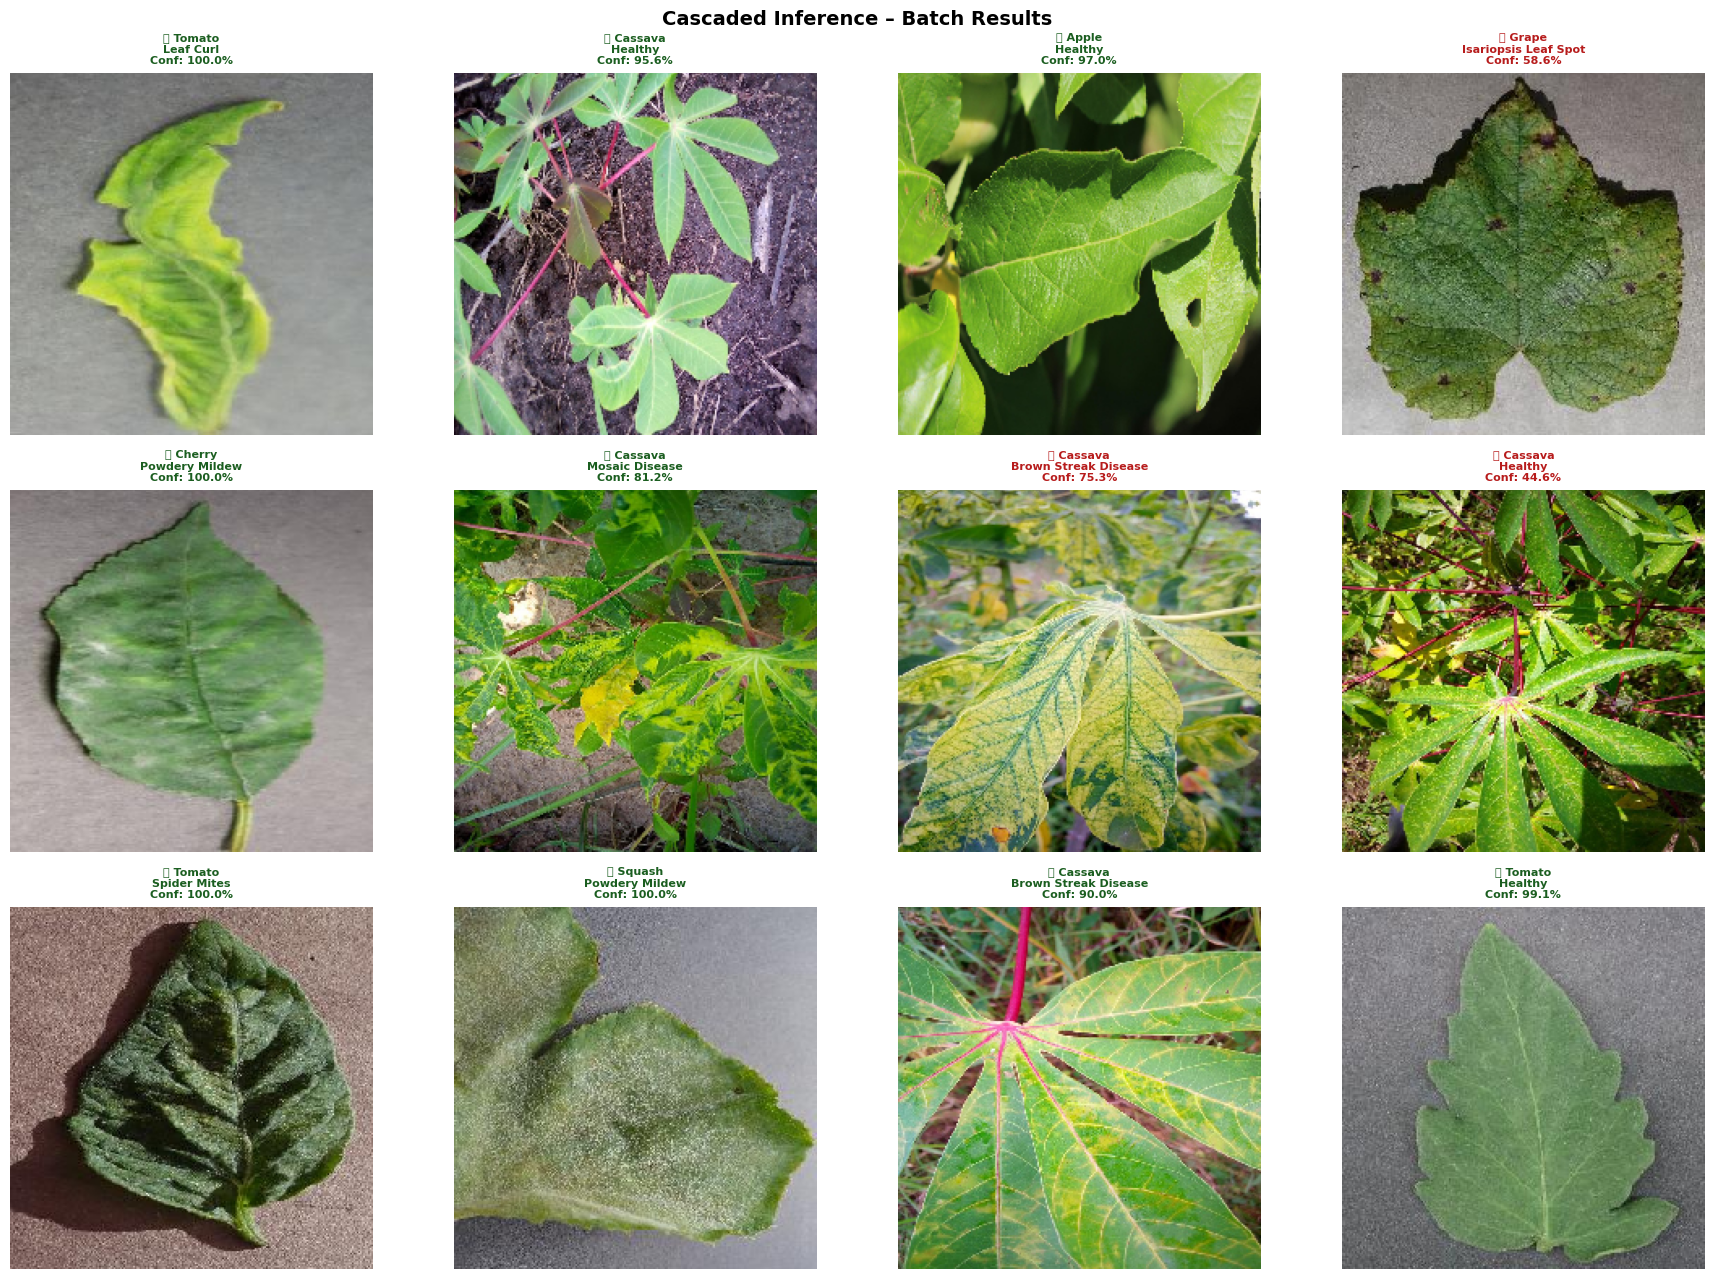

Saved → ../models/batch_predictions.png


In [7]:
fig, axes = plt.subplots(3, 4, figsize=(18, 13))
fig.suptitle("Cascaded Inference – Batch Results", fontsize=14, fontweight="bold")

for ax, r in zip(axes.flat, results):
    img = load_img(r["path"], target_size=IMAGE_SIZE)
    ax.imshow(img)

    correct = r["true_class"] == r["predicted_class"]
    color   = "#1B5E20" if correct else "#B71C1C"    # dark green / dark red
    marker  = "✅" if correct else "❌"

    ax.set_title(
        f"{marker} {r['plant']}\n{r['disease']}\nConf: {r['confidence']:.1%}",
        fontsize=8,
        color=color,
        fontweight="bold",
    )
    ax.axis("off")

    # Coloured border to indicate correct/incorrect
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2.5)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig("../models/batch_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../models/batch_predictions.png")

## 6 · Stage-1 confidence distribution

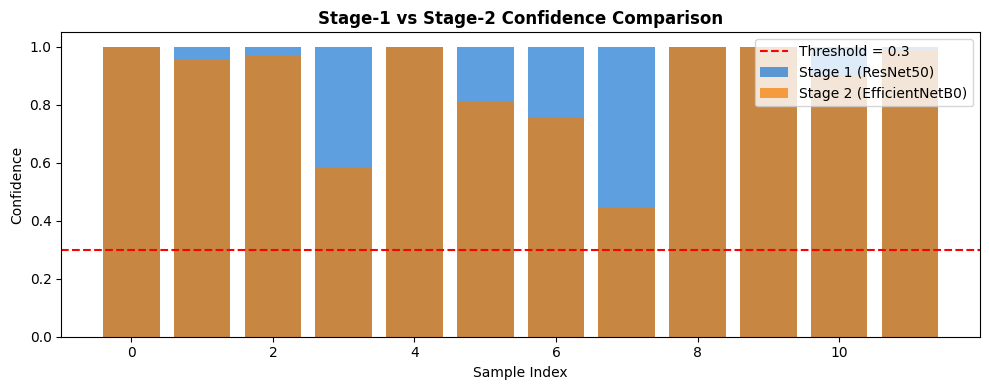

In [8]:
stage1_confs = [r["stage1_confidence"] for r in results]
stage2_confs = [r["confidence"]        for r in results]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(results)), stage1_confs, alpha=0.7, label="Stage 1 (ResNet50)",      color="#1976D2")
ax.bar(range(len(results)), stage2_confs, alpha=0.7, label="Stage 2 (EfficientNetB0)",color="#F57C00")
ax.axhline(CONFIDENCE_THRESHOLD, linestyle="--", color="red", label=f"Threshold = {CONFIDENCE_THRESHOLD}")
ax.set_xlabel("Sample Index")
ax.set_ylabel("Confidence")
ax.set_title("Stage-1 vs Stage-2 Confidence Comparison", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("../models/confidence_comparison.png", dpi=150, bbox_inches="tight")
plt.show()